# Dialogue Act Tagging

Dialogue act (DA) tagging is an essential step in the development of dialog systems. DA tagging is a problem that is usually solved using supervised machine learning techniques, which all require a large amount of manually labeled data. For DA tagging, a variety of methods have been investigated. In this lab, we'll look at two different DA classification models. The Switchboard Dialog Act Corpus is being used for training.
Corpus can be downloaded from http://compprag.christopherpotts.net/swda.html.


In [1]:
!wget 'https://github.com/juntaoy/ECS7001_LAB_DATASETS/raw/refs/heads/main/DA_data.zip'
!unzip DA_data.zip -x __MACOSX/*

--2025-04-19 04:10:10--  https://github.com/juntaoy/ECS7001_LAB_DATASETS/raw/refs/heads/main/DA_data.zip
Resolving github.com (github.com)... 20.26.156.215
Connecting to github.com (github.com)|20.26.156.215|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/juntaoy/ECS7001_LAB_DATASETS/refs/heads/main/DA_data.zip [following]
--2025-04-19 04:10:10--  https://raw.githubusercontent.com/juntaoy/ECS7001_LAB_DATASETS/refs/heads/main/DA_data.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14495014 (14M) [application/zip]
Saving to: ‘DA_data.zip’

DA_data.zip         100%[===================>]  13.82M  --.-KB/s    in 0.03s   

2025-04-19 04:10:11 (458 MB/s) - ‘DA_data.zip’ saved [14495014/14495014]



The downloaded dataset should be kept in a data folder in the same directory as this file.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset, TensorDataset

import glob
import re
import pandas as pd
import numpy as np
import sklearn.metrics
import matplotlib.pyplot as plt
from tqdm import tqdm_notebook as tqdm

In [3]:
f = glob.glob("swda/sw*/sw*.csv")
frames = []
for i in range(0, len(f)):
    frames.append(pd.read_csv(f[i]))

result = pd.concat(frames, ignore_index=True)


In [4]:
print("Number of converations in the dataset:",len(result))


Number of converations in the dataset: 223606


The dataset has many different features, we are only using act_tag and text for this training.


In [5]:
reduced_df = result[['act_tag','text']]


Reduce the number of tags to 43 by combining them and converting them to generic tags.

In [6]:
# Imported from "https://github.com/cgpotts/swda"
# Convert the combination tags to the generic 43 tags

import re
def damsl_act_tag(input):
        """
        Seeks to duplicate the tag simplification described at the
        Coders' Manual: http://www.stanford.edu/~jurafsky/ws97/manual.august1.html
        """
        d_tags = []
        tags = re.split(r"\s*[,;]\s*", input)
        for tag in tags:
            if tag in ('qy^d', 'qw^d', 'b^m'): pass
            elif tag == 'nn^e': tag = 'ng'
            elif tag == 'ny^e': tag = 'na'
            else:
                tag = re.sub(r'(.)\^.*', r'\1', tag)
                tag = re.sub(r'[\(\)@*]', '', tag)
                if tag in ('qr', 'qy'):                         tag = 'qy'
                elif tag in ('fe', 'ba'):                       tag = 'ba'
                elif tag in ('oo', 'co', 'cc'):                 tag = 'oo_co_cc'
                elif tag in ('fx', 'sv'):                       tag = 'sv'
                elif tag in ('aap', 'am'):                      tag = 'aap_am'
                elif tag in ('arp', 'nd'):                      tag = 'arp_nd'
                elif tag in ('fo', 'o', 'fw', '"', 'by', 'bc'): tag = 'fo_o_fw_"_by_bc'
            d_tags.append(tag)
        # Dan J says (p.c.) that it makes sense to take the first;
        # there are only a handful of examples with 2 tags here.
        return d_tags[0]

In [7]:
reduced_df["act_tag"] = reduced_df["act_tag"].apply(lambda x: damsl_act_tag(x))

/tmp/ipykernel_93/1040889475.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reduced_df["act_tag"] = reduced_df["act_tag"].apply(lambda x: damsl_act_tag(x))


This dataset contains 43 tags. Yes-No-Question ('qy'), Statement-non-opinion ('sd'), and Statement-opinion ('sv') are some of the tags. Tags information can be found here http://compprag.christopherpotts.net/swda.html#tags.


You can check the frequency of tags.

To get unique tags:

In [8]:
unique_tags = set()
for tag in reduced_df['act_tag']:
    unique_tags.add(tag)

In [9]:
tag_dict = {t:i for i,t in enumerate(list(unique_tags))}

In [10]:
tags_encoding = []
for i in range(0, len(reduced_df)):
    tags_encoding.append(tag_dict[reduced_df['act_tag'].iloc[i]])

The tags are one hot encoded.

To create sentence embeddings:

In [11]:
sentences = []
for i in range(0, len(reduced_df)):
    sentences.append(reduced_df['text'].iloc[i].split(" "))


In [12]:
wordvectors = {}
index = 1
for s in sentences:
    for w in s:
        if w not in wordvectors:
            wordvectors[w] = index
            index += 1

In [13]:
sentence_embeddings = []
for s in sentences:
    sentence_emb = []
    for w in s:
        sentence_emb.append(wordvectors[w])
    sentence_embeddings.append(sentence_emb)


The dataset is divided into two sections: test and training.

In [14]:
from sklearn.model_selection import train_test_split
import numpy as np
X_train, X_test, y_train, y_test = train_test_split(sentence_embeddings, np.array(tags_encoding),shuffle=False, stratify=None)


Pad each utterance to make them all the same length.




In [15]:
MAX_LENGTH = 150

In [16]:
print(X_train[1],y_train[1])

[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 3] 20


In [17]:
def pad_sequences(sequences, maxlen):
    return [seq[:maxlen] + [0] * (maxlen - len(seq)) for seq in sequences]

train_sentences_X = pad_sequences(X_train, maxlen=MAX_LENGTH)
test_sentences_X = pad_sequences(X_test, maxlen=MAX_LENGTH)

In [18]:
# Split Train into Train and Validation - about 10% into validation - In order to validate the model as it is training

train_input = train_sentences_X[:140000]
val_input = train_sentences_X[140000:]

train_labels = y_train[:140000]
val_labels = y_train[140000:]


In [19]:
np.array(train_input[11052])


array([  17,  832, 1345,   19,    3,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0])

In [20]:
sentence_embeddings[11052]

[17, 832, 1345, 19, 3]

In [21]:
train_labels[11052]

np.int64(34)

# Model 1 -

This first model has an architecture of:

- Embedding  
- BLSTM  
- Fully Connected Layer

The model architecture is as follows: Embedding Layer (to generate word
embeddings). Next layer Bidirectional LSTM. Feed forward layer with number of neurons = number of tags.


In [22]:
VOCAB_SIZE = len(wordvectors)+1 # 43,731
EMBED_SIZE = 100 # arbitary
HIDDEN_SIZE = len(unique_tags)

In [43]:
import torch.nn.functional as F
class BiLSTMModel(nn.Module):
    """
    Task 1 1/4

    Begin
    """
    def __init__(self, vocab_size, embed_size, hidden_size, max_length):
        super(BiLSTMModel, self).__init__()

        # Include 2 BLSTM layers, in order to capture both the forward and backward hidden states

        # Embedding layer
        # Bidirectional 1
        # Bidirectional 2
        # Dense layer
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_size)
        
        # First bidirectional LSTM
        self.bilstm1 = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden_size,
            bidirectional=True,
            batch_first=True
        )
        
        # Second bidirectional LSTM
        self.bilstm2 = nn.LSTM(
            input_size=2*hidden_size,  # Double input size for bidirectional
            hidden_size=hidden_size,
            bidirectional=True,
            batch_first=True
        )
        
        # Final dense layer
        self.fc = nn.Linear(2*hidden_size, hidden_size)  # 2*hidden_size for bidirectional output




    def forward(self, x):
        """
        x shape: (batch_size, seq_length)
        """
        # x shape: (batch_size, seq_length)
        embeddings = self.embedding(x)  # (batch_size, seq_len, embed_size)
        
        # First BiLSTM
        lstm1_out, _ = self.bilstm1(embeddings)  # (batch_size, seq_len, 2*hidden_size)
        
        # Second BiLSTM
        lstm2_out, (hidden, _) = self.bilstm2(lstm1_out)  # hidden shape: (2, batch_size, hidden_size)
        
        # Concatenate final forward/backward hidden states
        hidden_concat = torch.cat((hidden[-2], hidden[-1]), dim=1)  # (batch_size, 2*hidden_size)
        
        # Final classification
        logits = self.fc(hidden_concat)  # (batch_size, hidden_size)
        probs = F.log_softmax(logits, dim=1)



        return probs
    """
    End Task 1 1/4
    """

# Instantiate the model
model = BiLSTMModel(
    vocab_size=VOCAB_SIZE,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    max_length=MAX_LENGTH
)
# Print model summary (PyTorch-style)
print(model)

BiLSTMModel(
  (embedding): Embedding(43732, 100)
  (bilstm1): LSTM(100, 43, batch_first=True, bidirectional=True)
  (bilstm2): LSTM(86, 43, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=86, out_features=43, bias=True)
)


In [44]:
train_input_t = torch.Tensor(train_input)
train_labels_t = torch.Tensor(train_labels)
val_input_t = torch.Tensor(val_input)
val_labels_t = torch.Tensor(val_labels)
test_sentences_X_t = torch.Tensor(test_sentences_X)
y_test_t = torch.Tensor(y_test)

train_dataset = TensorDataset(train_input_t, train_labels_t)
val_dataset = TensorDataset(val_input_t, val_labels_t)
test_dataset = TensorDataset(test_sentences_X_t, y_test_t)

In [45]:

def train(model, train_dataset, val_dataset, epoch_num, lr, batch_size=1, device="cpu", weight=None):
    model.train()
    model = model.to(device)
    if weight:
       weight = torch.Tensor(weight).to(device)
    criterion = nn.CrossEntropyLoss(weight=weight).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    for epoch in range(epoch_num):
      model.train()
      total_loss = 0.0
      correct = 0
      """
      Task 1 2/3

      Begin
      """
      for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(torch.int32).to(device)
        batch_y = batch_y.type(torch.LongTensor).to(device)
        
        # Forward pass
        outputs = model(batch_x)
        
        # Calculate loss
        loss = criterion(outputs, batch_y)
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Compute training accuracy
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == batch_y).sum().item()
        total_loss += loss.item() * batch_x.size(0)





      avg_loss = total_loss / len(train_dataset)
      accuracy = correct / len(train_dataset)

      # Validation
      model.eval()
      val_loss = 0.0
      val_correct = 0
      with torch.no_grad():
          for val_x, val_y in val_loader:
              val_x = val_x.to(torch.int32).to(device)
              val_y = val_y.type(torch.LongTensor).to(device)

              # calculate the validation loss
              # calculate the validation accuracy
              # Forward pass
              outputs = model(val_x)
                
              # Calculate validation loss
              loss = criterion(outputs, val_y)
              val_loss += loss.item() * val_x.size(0)
                
              # Calculate validation accuracy
              _, predicted = torch.max(outputs.data, 1)
              val_correct += (predicted == val_y).sum().item()




      """
      End Task 1 2/3
      """
      val_loss /= len(val_dataset)
      val_accuracy = val_correct / len(val_dataset)

      print(f"Epoch [{epoch+1}/{epoch_num}] "
            f"Train Loss: {avg_loss:.4f}, Train Acc: {accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

In [46]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train(model, train_dataset, val_dataset, 5, 1e-4, 256, device)

Epoch [1/5] Train Loss: 2.2530, Train Acc: 0.4623 | Val Loss: 1.7072, Val Acc: 0.5167
Epoch [2/5] Train Loss: 1.5785, Train Acc: 0.5702 | Val Loss: 1.4848, Val Acc: 0.5750
Epoch [3/5] Train Loss: 1.4123, Train Acc: 0.6072 | Val Loss: 1.3731, Val Acc: 0.6057
Epoch [4/5] Train Loss: 1.3264, Train Acc: 0.6223 | Val Loss: 1.3091, Val Acc: 0.6147
Epoch [5/5] Train Loss: 1.2594, Train Acc: 0.6344 | Val Loss: 1.2477, Val Acc: 0.6278


In [47]:
def eval(model, test_dataset, batch_size=1, device="cpu"):
    model.eval()
    model.to(device)
    test_loss = 0.0
    test_correct = 0

    criterion = nn.CrossEntropyLoss()
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for test_x, test_y in test_loader:
            test_x = test_x.to(torch.int32).to(device)
            test_y = test_y.type(torch.LongTensor).to(device)

            """
            Task 1 3/3

            Begin
            """

            # Forward pass
            outputs = model(test_x)
            
            # Calculate test loss
            loss = criterion(outputs, test_y)
            test_loss += loss.item() * test_x.size(0)
            
            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            test_correct += (predicted == test_y).sum().item()

            """
            End Task 1 3/3
            """


    test_loss /= len(test_dataset)
    test_accuracy = test_correct / len(test_dataset)

    print(f"Overall Loss: {test_loss:.4f}, Acc: {test_accuracy:.4f}")

In [48]:
eval(model, test_dataset, 100, device)

Overall Loss: 1.2981, Acc: 0.6206


## Evaluation




You should look at the accuracy of some minority classes in addition to overall accuracy. Signal-non-understanding ('br') is a good indicator of "other-repair," or situations in which the other conversational participant tries to correct the speaker's mistake. In dialogue summarization, the term "summarize/reformulate" ('bf') has been used. Report on the system's accuracy in predicting these classes, as well as any common errors you notice.

## Minority Classes

In [49]:
"""
Task 2 1/2

Begin
"""
# Generate predictions for the test data
def predict(model, test_dataset, batch_size=100, device="cpu"):
    model.eval()
    model.to(device)

    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    predictions = []
    
    with torch.no_grad():
        for test_x, test_y in test_loader:
            test_x = test_x.to(torch.int32).to(device)
            
            # Forward pass
            outputs = model(test_x)
            
            # Get predicted class indices
            _, preds = torch.max(outputs, 1)
            predictions.append(preds.cpu())
    
    # Concatenate all batch predictions
    return torch.cat(predictions).numpy()

label_pred = predict(model, test_dataset, 100, device)


In [50]:
from sklearn.metrics import confusion_matrix
# Build the confusion matrix off these predictions
matrix = confusion_matrix(y_test, label_pred)
print(label_pred)
print(y_test)

[13 38 38 ... 28 38 38]
[13  9 38 ... 28  9  9]


In [51]:
# Build the confusion matrix off these predictions
matrix_balanced = confusion_matrix(y_test, label_pred)

# Calculate Accuracies for "br" and "bf"
br_idx = tag_dict['br']
bf_idx = tag_dict['bf']

br_accuracy = (matrix_balanced[br_idx, br_idx]/matrix_balanced[br_idx].sum() 
               if matrix_balanced[br_idx].sum() > 0 else 0)
bf_accuracy = (matrix_balanced[bf_idx, bf_idx]/matrix_balanced[bf_idx].sum() 
               if matrix_balanced[bf_idx].sum() > 0 else 0)

print(f" Model - 'br' accuracy: {br_accuracy:.2%}")
print(f" Model - 'bf' accuracy: {bf_accuracy:.2%}")

"""
End Task 2 2/2
"""

 Model - 'br' accuracy: 0.00%
 Model - 'bf' accuracy: 0.00%


'\nEnd Task 2 2/2\n'

## Minority Classes



Minority classes are frequently misidentified as majority classes, owing to the fact that majority classes have significantly more data and thus can be trained on. With 33 percent and 17 percent, respectively, the classes "sd" (40) and "b" (10) are the most common here.




## Minority Class showcase
The frequencies of the data are plotted in the graph below. This illustrates how some classes are common, while the majority of classes are rare.

Only 0.13 percent of the data belongs to the "br" class, while 0.42 percent belongs to the "bf" class.

In [52]:
# Print the frequency of the "br" and "bf" classes
value_counts = reduced_df["act_tag"].value_counts()
bf_frequency = value_counts["bf"]/sum(value_counts)
print("bf frequency: " + str(bf_frequency*100) + "%")

br_frequency = value_counts["br"]/sum(value_counts)
print("br frequency: " + str(br_frequency*100) + "%")

bf frequency: 0.42977379855638936%
br frequency: 0.13371734211067682%


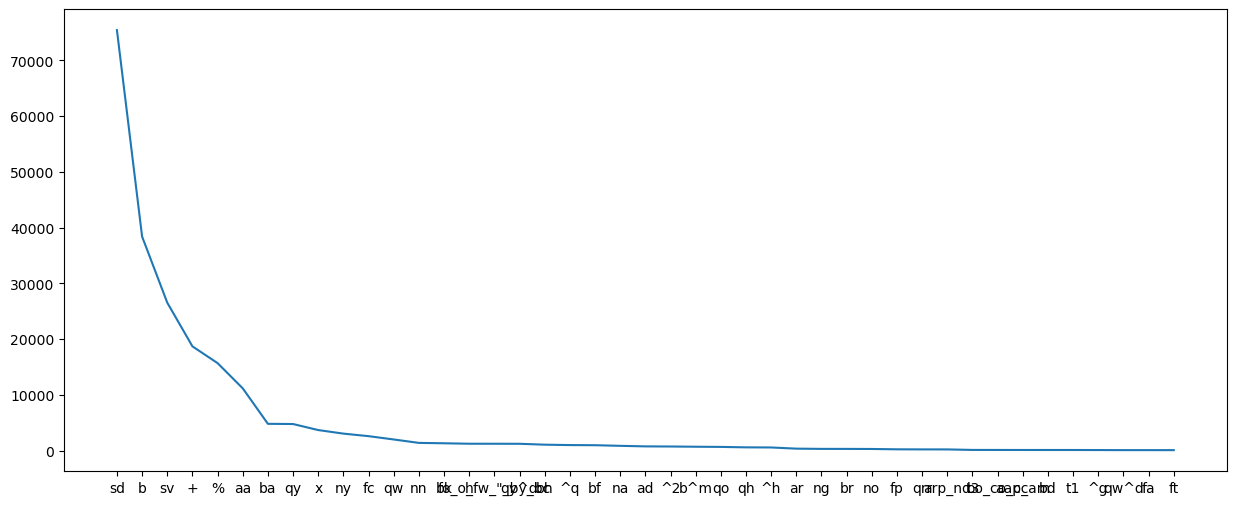

In [53]:
# Plot the frequencies of the classes
plt.figure(figsize=(15,6))
plt.plot(value_counts)

# Model 2 - Balanced Network


As the dataset is highly imbalanced, we can simply weight up the minority classes proportionally to their underrepresentation while training.

In [54]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(tags_encoding), y=tags_encoding)
print(class_weights)
d_class_weights = dict(enumerate(class_weights))
d_class_weights = list(d_class_weights.values())


[ 5.41117537 49.52513843 65.00174419 50.00134168  1.41384979 17.16217668
 50.4867916   1.09246629  3.97260469  0.19603195  3.77368616  2.01165939
  7.12347881  0.33159926  6.91507917  4.27291663 55.91547887 15.07286822
  4.23809253  0.46608762  2.61313544  1.08403993 18.18230607  6.11062225
  7.54737233  4.25543333  5.27397519  1.71057222  0.27821623  7.91497646
 17.39177102 24.76256921 47.27399577 44.44563705  0.13548734 25.12144703
 23.11173127  8.9967812   0.06896462  4.91971574 66.66845558 65.82455107
  9.33597762]


## Define & Train the model

In [55]:
"""
Task 2 2/2

Begin
"""
# Instantiate the model with class weights
model_balanced = BiLSTMModel(
    vocab_size=VOCAB_SIZE,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    max_length=MAX_LENGTH
).to(device)

In [56]:
# Train the balanced network - Seems to take long time to achieve good accuracy?
train(model_balanced, train_dataset, val_dataset, 
      epoch_num=5, lr=1e-4, batch_size=256, 
      device=device, weight=d_class_weights)

Epoch [1/5] Train Loss: 3.6743, Train Acc: 0.2145 | Val Loss: 3.5320, Val Acc: 0.4824
Epoch [2/5] Train Loss: 3.4174, Train Acc: 0.4729 | Val Loss: 3.2888, Val Acc: 0.4751
Epoch [3/5] Train Loss: 3.1800, Train Acc: 0.4451 | Val Loss: 3.0811, Val Acc: 0.3724
Epoch [4/5] Train Loss: 2.9749, Train Acc: 0.3770 | Val Loss: 2.9210, Val Acc: 0.3565
Epoch [5/5] Train Loss: 2.8089, Train Acc: 0.3700 | Val Loss: 2.8030, Val Acc: 0.3709


## Test the model

In [57]:
# Overall Accuracy
eval(model_balanced, test_dataset, 100, device)



Overall Loss: 2.5065, Acc: 0.3749


In [58]:
# Generate predictions for the test data
label_pred = predict(model_balanced, test_dataset, 100, device)

## Balanced network evaluation

Report the overall accuracy and the accuracy of  'br' and 'bf'  classes. Suggest other ways to handle imbalanced classes.

In [59]:
# Build the confusion matrix off these predictions
matrix_balanced = confusion_matrix(y_test, label_pred)

# Calculate Accuracies for "br" and "bf"
br_idx = tag_dict['br']
bf_idx = tag_dict['bf']

br_accuracy = (matrix_balanced[br_idx, br_idx]/matrix_balanced[br_idx].sum() 
               if matrix_balanced[br_idx].sum() > 0 else 0)
bf_accuracy = (matrix_balanced[bf_idx, bf_idx]/matrix_balanced[bf_idx].sum() 
               if matrix_balanced[bf_idx].sum() > 0 else 0)

print(f"Balanced Model - 'br' accuracy: {br_accuracy:.2%}")
print(f"Balanced Model - 'bf' accuracy: {bf_accuracy:.2%}")

"""
End Task 2 2/2
"""

Balanced Model - 'br' accuracy: 46.94%
Balanced Model - 'bf' accuracy: 0.43%


'\nEnd Task 2 2/2\n'





### Explanation



### Other ways to handle imbalanced classes


- The model can be turned into multiple single-class classifiers, giving a confidence score for each of the classes. Instead of just taking the highest confidence class, the model can run the individual classifiers in ascending order of frequency of the classes in the training corpus.  The first classifier to classify the data point over a certain confidence threshold determines the class given to the example. This gives chance for the minority class classifiers to classify before the frequent classes arrive with their more confident predicitions.

- Transfer Learning could also be implemented, to initialise weights on a larger dataset, where these minority classes may be prevelant. This would allow fine-tuning with the small data for this particular application.

Can we improve things by using context information?  Next we try to build a model which predicts DA tag from the sequence of
previous DA tags, plus the utterance representation.

# Using Context for Dialog Act Classification
We expect there is valuable sequential information among the DA tags. So in this section we apply a BiLSTM on top of the sentence CNN representation. The CNN model learns textual information in each utterance for DA classification. Here, we use bidirectional-LSTM (BLSTM) to learn the context before and after the current utterance.

To make it easier to train, we combined all of the utterances into one long sequence rather than breaking them up into individual dialogues.

## Define the model

This model has an architecture of:

- Word Embedding
- CNN
- Bidirectional LSTM
- Fully-Connected output


## CNN


This is classical CNN layer used to convolve over embedings tensor and gether useful information from it. The data is represented by hierarchy of features, which can be modelled using a CNN. We transform/reshape conv output to 2d matrix. Then we pass it to the max pooling layer that applies the max pool operation on windows of different sizes.

## BiLSTM

This is used to create LSTM layers. The data we’re working with has temporal properties which we want to model as well — hence the use of a LSTM. You should create a BiLSTM.
    

Concatenate 2 last layers and create the output layer
network

In [60]:
import torch.nn.functional as F

filter_sizes = [3,4,5]
num_filters = 64
drop = 0.2
VOCAB_SIZE = len(wordvectors)+1 # 43,731
MAX_LENGTH = 150
EMBED_SIZE = 100 # arbitary
HIDDEN_SIZE = len(unique_tags)

class CNN_BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, filter_sizes, num_filters, dropout=0.2):
        super(CNN_BiLSTM, self).__init__()

        # Embedding layer
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_size)

        # Convolution blocks (Conv2D + BatchNorm + ReLU), one per filter size
        self.conv_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels=1,
                          out_channels=num_filters,
                          kernel_size=(fs, embed_size),  # (filter_size, embedding_dim)
                          stride=1,
                          padding=0),
                nn.BatchNorm2d(num_filters),
                nn.ReLU()
            ) for fs in filter_sizes
        ])

        # After max pooling each convolution output, we concatenate them.
        # The shape after concatenation will be [batch_size, len(filter_sizes), 1, num_filters].
        # We'll flatten it to [batch_size, 1, len(filter_sizes)*num_filters].

        # First Dense layer (Dense_1) that maps CNN outputs down to EMBED_SIZE
        self.dense_1 = nn.Linear(num_filters * len(filter_sizes), embed_size)
        self.dropout_1 = nn.Dropout(dropout)

        # Two stacked BiLSTM layers
        # - The first BiLSTM has EMBED_SIZE hidden units, bidirectional => output_dim=2*EMBED_SIZE
        # - The second BiLSTM takes 2*EMBED_SIZE as input (from the first BiLSTM if return_sequences=True).
        #   Since it's bidirectional, final output_dim of the second BiLSTM is 2*EMBED_SIZE as well.
        self.blstm1 = nn.LSTM(input_size=embed_size, hidden_size=embed_size,
                              batch_first=True, bidirectional=True)
        self.blstm2 = nn.LSTM(input_size=2*embed_size, hidden_size=embed_size,
                              batch_first=True, bidirectional=True)

        # Second Dense layer (Dense_2) after the second BiLSTM
        # This projects 2*EMBED_SIZE down to EMBED_SIZE
        self.dense_2 = nn.Linear(2 * embed_size, embed_size)
        self.dropout_2 = nn.Dropout(dropout)

        # Final output layer (Output)
        self.output = nn.Linear(embed_size + embed_size, hidden_size)  # concatenating two EMBED_SIZE vectors

    def forward(self, x):
        """
        x shape: [batch_size, MAX_LENGTH]
        """
        # 1) Embedding
        x = self.embedding(x)               # [batch_size, MAX_LENGTH, EMBED_SIZE]
        x = x.unsqueeze(1)                  # [batch_size, 1, MAX_LENGTH, EMBED_SIZE] so we can apply Conv2D

        # 2) Parallel Convolutions -> BN -> ReLU -> MaxPool
        # Each conv_block expects input of shape [batch_size, 1, MAX_LENGTH, EMBED_SIZE].
        pooled_outputs = []
        for conv in self.conv_blocks:
            conv_out = conv(x)  # shape: [batch_size, num_filters, (MAX_LENGTH - fs + 1), 1]
            # Perform 2D max pooling across the variable spatial dimension conv_out.shape[2] and width=1
            # This collapses each feature map to a single value per filter.
            pooled = F.max_pool2d(conv_out, kernel_size=(conv_out.shape[2], conv_out.shape[3]))
            # Now shape: [batch_size, num_filters, 1, 1]
            pooled_outputs.append(pooled)

        """
        Task 3 1/2

        Begin
        """

        # Concatenate along the channel dimension (num_filters dimension)
        # After pooling, each block has shape [batch_size, num_filters, 1, 1].
        # concatenation => [batch_size, len(filter_sizes)*num_filters, 1, 1]
        x = torch.cat(pooled_outputs, dim=1)  # [batch_size, 3*num_filters, 1, 1]



        # 3) Flatten to [batch_size, 1, len(filter_sizes)*num_filters]
        x = x.view(x.size(0), 1, -1)


        # 4) Dense_1 + Dropout
        x = self.dense_1(x)                 # [batch_size, 1, EMBED_SIZE]
        x_dense = self.dropout_1(x)         # [batch_size, 1, EMBED_SIZE]

        # 5) BiLSTM_1 (return_sequences=True)
        #    Input shape: [batch_size, sequence_len, EMBED_SIZE]
        #    Output shape: [batch_size, sequence_len, 2*EMBED_SIZE]
        lstm1_out, _ = self.blstm1(x_dense) # [batch_size, 1, 2*EMBED_SIZE]

        # 6) BiLSTM_2 (no return_sequences => final hidden state)
        #    Input shape: [batch_size, sequence_len, 2*EMBED_SIZE]
        #    final_timestep shape: [2, batch_size, EMBED_SIZE]
        _, (hidden, _) = self.blstm2(lstm1_out)
        # Concatenate final forward/backward states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # [batch_size, 2*EMBED_SIZE]

        # 7) Dense_2 + Dropout
        lstm_out = self.dense_2(hidden)     # [batch_size, EMBED_SIZE]
        lstm_out = self.dropout_2(lstm_out) # [batch_size, EMBED_SIZE]

        # 8) Concatenate Flatten(dropout_1) and dropout_2
        #    Flatten(dropout_1) => shape [batch_size, EMBED_SIZE]
        #    out => [batch_size, EMBED_SIZE]
        # Note: dropout_1 was [batch_size, 1, EMBED_SIZE], so flatten the second dimension:
        combined = torch.cat([
                x_dense.view(x_dense.size(0), -1),  # Flatten CNN output
                lstm_out                            # BiLSTM output
            ], dim=1)                              # [batch_size, 2*EMBED_SIZE]

        # 9) Output layer
        logits = self.output(combined)       # [batch_size, HIDDEN_SIZE]

        """
        End Task 3 1/2
        """
        return logits

model_context = CNN_BiLSTM(
    vocab_size=VOCAB_SIZE,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    filter_sizes=filter_sizes,
    num_filters=num_filters,
    dropout=drop
)
print(model_context)

CNN_BiLSTM(
  (embedding): Embedding(43732, 100)
  (conv_blocks): ModuleList(
    (0): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 100), stride=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): Conv2d(1, 64, kernel_size=(4, 100), stride=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (2): Sequential(
      (0): Conv2d(1, 64, kernel_size=(5, 100), stride=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (dense_1): Linear(in_features=192, out_features=100, bias=True)
  (dropout_1): Dropout(p=0.2, inplace=False)
  (blstm1): LSTM(100, 100, batch_first=True, bidirectional=True)
  (blstm2): LSTM(200, 100, batch_first=True, bidirectional=True)
  (dense_2): Linear(in_features=200, out_features=100, bias=True)
  (dropout_2): Dr

Report your overall accuracy. Did context help disambiguate and better predict the minority classes ('br' and 'bf')? What are frequent errors? Show one positive example where adding context changed the prediction.
layer

In [62]:
"""
Task 3 2/2

Begin
"""

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train(model_context, train_dataset, val_dataset, 5, 1e-4, 256, device)
# Overall Accuracy
eval(model_context, test_dataset, 100, device)

# Generate predictions for the test data
label_pred = predict(model_context, test_dataset, 100, device)

# Build the confusion matrix off these predictions
matrix_balanced = confusion_matrix(y_test, label_pred)

# Calculate Accuracies for "br" and "bf"
br_idx = tag_dict['br']
bf_idx = tag_dict['bf']

br_accuracy = (matrix_balanced[br_idx, br_idx]/matrix_balanced[br_idx].sum() 
               if matrix_balanced[br_idx].sum() > 0 else 0)
bf_accuracy = (matrix_balanced[bf_idx, bf_idx]/matrix_balanced[bf_idx].sum() 
               if matrix_balanced[bf_idx].sum() > 0 else 0)

print(f"Context Model - 'br' accuracy: {br_accuracy:.2%}")
print(f"Context Model - 'bf' accuracy: {bf_accuracy:.2%}")



"""
End Task 3 2/2
"""

Epoch [1/5] Train Loss: 0.9872, Train Acc: 0.6971 | Val Loss: 1.0299, Val Acc: 0.6747
Epoch [2/5] Train Loss: 0.9597, Train Acc: 0.7038 | Val Loss: 1.0199, Val Acc: 0.6800
Epoch [3/5] Train Loss: 0.9351, Train Acc: 0.7101 | Val Loss: 1.0088, Val Acc: 0.6820
Epoch [4/5] Train Loss: 0.9146, Train Acc: 0.7158 | Val Loss: 1.0073, Val Acc: 0.6843
Epoch [5/5] Train Loss: 0.8933, Train Acc: 0.7216 | Val Loss: 1.0067, Val Acc: 0.6812
Overall Loss: 1.0307, Acc: 0.6802
Context Model - 'br' accuracy: 30.61%
Context Model - 'bf' accuracy: 0.00%


'\nEnd Task 3 2/2\n'